# Week 2: Hidden Anomalies in Observed Data

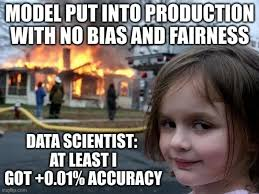

You receive three CSV files from a new collection of the same ACSIncome task:

- `week2_train_observed.csv`
- `week2_validation_observed.csv`
- `week2_test_features.csv`

You have received three new CSV files from a recent data collection effort for the ACSIncome task. However, this data was collected "in the wild" and has not been vetted. It may contain undocumented data-quality issues, distribution shifts, or inconsistent labels. 

You are **not** told whether a problem exists, what features are affected, or what caused the issues. Your task is to act and audit: you must explore the data, design robust checks to uncover issues, and critically interpret your findings to hypothesize what might be going wrong in the data pipeline. 

Do not jump directly to mitigation. A good audit strictly distinguishes between *observed evidence*, *hypotheses*, and *conclusions*.

In [ ]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("data")  # TODO: change if necessary

# In Colab you may instead upload the CSVs:
# from google.colab import files
# files.upload()

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
validation = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
test_features = pd.read_csv(DATA_DIR / "week2_test_features.csv")

print(train.shape, validation.shape, test_features.shape)
display(train.head())

(18000, 15) (6000, 15) (6000, 14)


,row_id,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,SEX_group,RACE_group,SURVEY_BATCH,income_observed
0,0,23.0,1.0,20.0,5.0,9130.0,48.0,2.0,40.0,1.0,1.0,Male,White,B04,0
1,1,57.0,1.0,21.0,1.0,3255.0,301.0,1.0,35.0,2.0,1.0,Female,White,B06,1
2,2,29.0,1.0,21.0,1.0,6800.0,6.0,0.0,48.0,1.0,1.0,Male,White,B02,1
3,3,42.0,6.0,17.0,1.0,6200.0,313.0,1.0,40.0,1.0,1.0,Male,White,B04,0
4,4,67.0,1.0,20.0,1.0,3601.0,48.0,0.0,6.0,2.0,2.0,Female,Black,B08,0


Hints: Design checks for schema, missingness, duplicates, impossible values, group sizes, target prevalence, and feature drift. Do not assume a column is safe merely because its name sounds administrative.

In [2]:
# TODO: implement a reusable dataset summary.
def dataset_summary(df, label=None):
    """
    Generates a comprehensive diagnostic summary of the dataset.
    """
    summary = {}
    
    # Schema & Missingness
    # Assesses data types and exact null counts/percentages across all columns.
    schema_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Count': df.isnull().sum(),
        'Missing (%)': (df.isnull().sum() / len(df)) * 100,
        'Unique Count': df.nunique()
    })
    summary['schema_and_missingness'] = schema_df
    
    # Duplicates
    # Checks for fully duplicated rows.
    summary['exact_duplicates'] = df.duplicated().sum()
    
    # Impossible Values (Numeric)
    # Extracts min, max, and percentiles to easily spot negative ages, percentages > 100, etc.
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        summary['numeric_distributions'] = df[numeric_cols].describe(
            percentiles=[0.01, 0.5, 0.99]
        ).T[['min', '1%', '50%', '99%', 'max', 'mean']]
        
    # Group Sizes (Categorical)
    # Identifies rare classes or dominant single values in categorical/object features.
    cat_cols = df.select_dtypes(exclude=[np.number]).columns
    cat_summary = {}
    for col in cat_cols:
        # Calculate percentages of the categories
        percentages = df[col].value_counts(dropna=False, normalize=True).head() * 100
        cat_summary[col] = percentages.to_dict()
    summary['categorical_top_groups'] = cat_summary
    
    # Target Prevalence
    # Checks class imbalance or continuous target distribution if a label is specified.
    if label and label in df.columns:
        if pd.api.types.is_numeric_dtype(df[label]) and df[label].nunique() > 10:
            # If the target is a numeric type
            summary['target_prevalence'] = df[label].describe()
        else:
            # If the target is a string or similar non-numeric type
            summary['target_prevalence'] = df[label].value_counts(dropna=False, normalize=True) * 100
            
    return summary

def print_summary(summary, title):
    print(f"--- {title} ---")
    
    print("\n--- Data Schema & Missingness ---")
    print(summary['schema_and_missingness'])

    print("\n--- Numeric Percentiles (Check for Impossible Values) ---")
    print(summary['numeric_distributions'])

    print("\n--- Exact Duplicate Rows ---")
    print(summary['exact_duplicates'])

    print("\n--- Group Sizes ---")
    print(summary['categorical_top_groups'])

    if 'target_prevalence' in summary.keys():
        print("\n--- Target Prevalence ---")
        print(summary['target_prevalence'])

def check_feature_drift(train, validation, test_features):
    palette = {
        "train": "#013220",       # Dark Green
        "validation": "#d95f02",  # Muted Orange
        "test": "#7570b3"         # Muted Purple
    }
    datasets = {"train": train, "validation": validation, "test": test_features}
    feature_columns = [c for c in train.columns if c not in ["row_id", "income_observed"]]

    fig, axes = plt.subplots(len(feature_columns) // 3, 3, figsize=(15, 3 * (len(feature_columns) // 3)))
    axes = axes.flatten()

    for ax, col in zip(axes, feature_columns):
        if pd.api.types.is_numeric_dtype(train[col]):
            for name, df in datasets.items():
                ax.hist(df[col].dropna(), bins=25, alpha=0.5, density=True, label=name, color=palette[name])
        else:
            props = pd.DataFrame({
                name: df[col].value_counts(normalize=True) for name, df in datasets.items()
            })
            colors = [palette[name] for name in props.columns]
            props.plot(kind="bar", ax=ax, legend=False, color=colors)

        ax.set_title(col)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [3]:
print_summary(summary=dataset_summary(train, label='income_observed'), title="Training Data")
print("----------------------------------------------------------")
print_summary(summary=dataset_summary(validation, label='income_observed'), title="Validation Data")
print("----------------------------------------------------------")
print_summary(summary=dataset_summary(test_features, label='income_observed'), title="Test Features")

--- Training Data ---

--- Data Schema & Missingness ---
                Data Type  Missing Count  Missing (%)  Unique Count
row_id              int64              0          0.0         18000
AGEP              float64              0          0.0            73
COW               float64              0          0.0             8
SCHL              float64              0          0.0            24
MAR               float64              0          0.0             5
OCCP              float64              0          0.0           515
POBP              float64              0          0.0           184
RELP              float64              0          0.0            18
WKHP              float64              0          0.0            93
SEX               float64              0          0.0             2
RAC1P             float64              0          0.0             9
SEX_group             str              0          0.0             2
RACE_group            str              0          0.0      

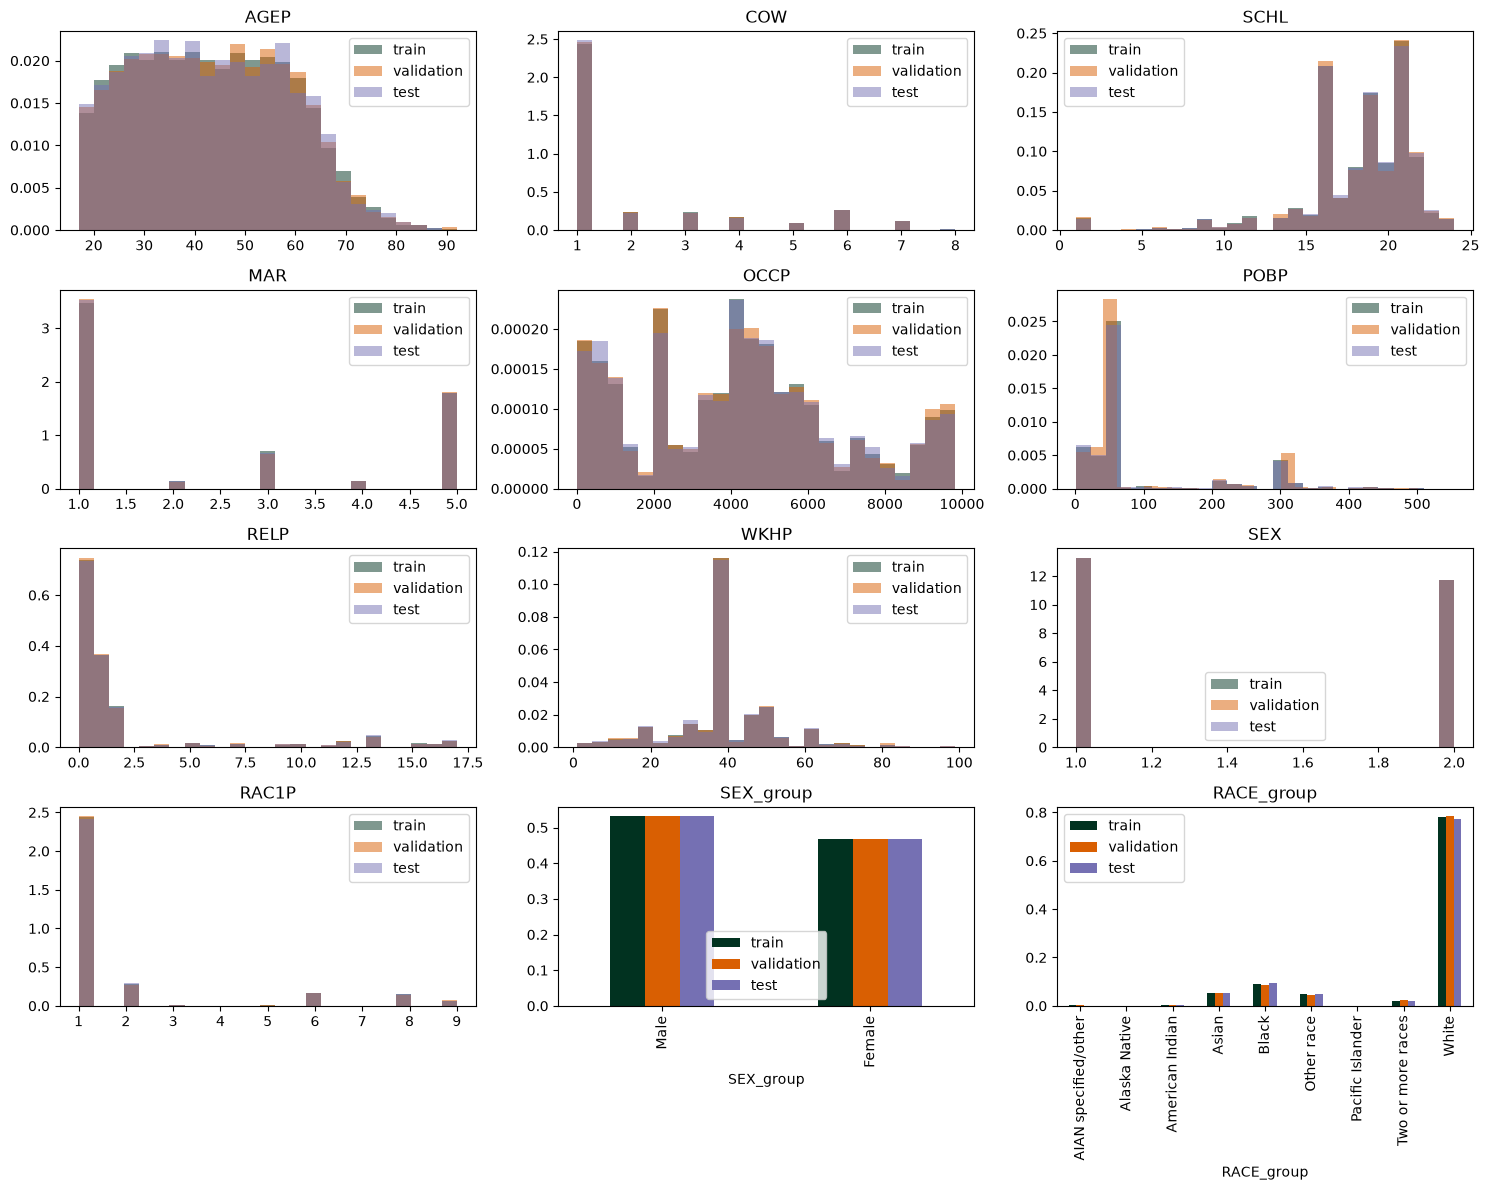

In [4]:
check_feature_drift(train, validation, test_features)

Hints: Build at least two models, including a simple interpretable baseline. Decide which features belong in the model. Keep `row_id` out of the predictive feature set. Keep sensitive attributes available for auditing even if you exclude them from prediction.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

LABEL = "income_observed"
ID = "row_id"
SENSITIVE = "SEX_group"

# TODO: choose features and justify exclusions.
#FEATURE_COLUMNS = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP"]
NUMERIC_FEATURES = ["AGEP", "SCHL", "WKHP"]
CATEGORICAL_FEATURES = ["COW", "MAR", "OCCP", "POBP", "RELP"]
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [SENSITIVE]

# TODO: write a model factory that handles numeric and categorical columns.
def make_model(frame):
    numeric = [c for c in NUMERIC_FEATURES if c in frame.columns]
    categorical = [c for c in CATEGORICAL_FEATURES if c in frame.columns]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000)),
    ])

# TODO: fit a baseline on observed training labels and evaluate against observed validation labels.
lr_model = make_model(train)
lr_model.fit(train[FEATURE_COLUMNS], train[LABEL])

lr_val_pred = lr_model.predict(validation[FEATURE_COLUMNS])
lr_val_proba = lr_model.predict_proba(validation[FEATURE_COLUMNS])[:,1]
lr_val_acc = accuracy_score(validation[LABEL], lr_val_pred)

baseline_pred = (validation['SCHL'] >= 21).astype(int) # 21 Bachelor's Degree
baseline_val_acc = accuracy_score(validation["income_observed"], baseline_pred)


print("Logistic Regression Validation Accuracy:", lr_val_acc)
print("SCHL Baseline Accuracy:", baseline_val_acc)

Logistic Regression Validation Accuracy: 0.7861666666666667
SCHL Baseline Accuracy: 0.702


Compute overall and group-specific utility, selection rate, TPR, FPR, PPV, NPV, equalized-odds components, and probability metrics. Report counts and uncertainty. Explicitly label every result as being evaluated against $Y^{obs}$.

In [6]:
from fairlearn.metrics import MetricFrame, selection_rate, count, equalized_odds_difference, equalized_odds_ratio
from sklearn.metrics import confusion_matrix, precision_score, recall_score, balanced_accuracy_score


# TODO: implement robust metric functions.
def true_positive_rate(y_true, y_pred):
    return recall_score(y_true, y_pred, pos_label=1, zero_division=0)

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denominator = tn + fp
    return fp / denominator if denominator > 0 else np.nan

def positive_predictive_value(y_true, y_pred):
    return precision_score(y_true, y_pred, pos_label=1, zero_division=0)

def negative_predictive_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denominator = tn + fn
    return tn / denominator  if denominator else np.nan

LABEL_METRICS = {
    "count": count,
    "selection_rate": selection_rate,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "tpr": true_positive_rate,
    "fpr": false_positive_rate,
    "ppv": positive_predictive_value,
    "npv": negative_predictive_value,
}


def fairness_summary(y_true, y_pred, sens_df):
    # Compute metrics
    mf = MetricFrame(
        metrics=LABEL_METRICS,
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sens_df,
    )
    
    print("Overall threshold metrics")
    display(pd.Series(mf.overall))
    print("By group")
    display(mf.by_group)
    
    disparity_summary = pd.Series({
        "equalized_odds_difference" : equalized_odds_difference(
            y_true=y_true, y_pred=y_pred, sensitive_features=sens_df
        ),
        "equalized_odds_ratio": equalized_odds_ratio(
            y_true=y_true, y_pred=y_pred, sensitive_features=sens_df
        ),
    })
    
    display(disparity_summary)
    
# TODO: construct MetricFrame for SEX_group and at least one intersection.
fairness_summary(validation[LABEL], lr_val_pred, validation[["SEX_group"]])

fairness_summary(validation[LABEL], lr_val_pred, validation[["SEX_group", "RACE_group"]])

Overall threshold metrics


count                6000.000000
selection_rate          0.296167
accuracy                0.786167
balanced_accuracy       0.745591
tpr                     0.623131
fpr                     0.131948
ppv                     0.703433
npv                     0.820980
dtype: float64

By group


,count,selection_rate,accuracy,balanced_accuracy,tpr,fpr,ppv,npv
SEX_group,,,,,,,,
Female,2812.0,0.216572,0.790541,0.692428,0.516026,0.13117,0.528736,0.862914
Male,3188.0,0.366374,0.782309,0.769300,0.671491,0.13289,0.794521,0.775248


equalized_odds_difference    0.155465
equalized_odds_ratio         0.768478
dtype: float64

...

/home/willi/miniconda3/envs/RAI/lib/python3.13/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


count                6000.000000
selection_rate          0.296167
accuracy                0.786167
balanced_accuracy       0.745591
tpr                     0.623131
fpr                     0.131948
ppv                     0.703433
npv                     0.820980
dtype: float64

By group


count  selection_rate  accuracy  \
SEX_group RACE_group                                               
Female    AIAN specified/other     6.0        0.166667  1.000000   
          American Indian          9.0        0.111111  0.777778   
          Asian                  153.0        0.320261  0.751634   
          Black                  285.0        0.122807  0.824561   
          Other race             116.0        0.112069  0.844828   
          Pacific Islander         2.0        0.000000  0.500000   
          Two or more races       55.0        0.236364  0.709091   
          White                 2186.0        0.227356  0.787740   
Male      AIAN specified/other     9.0        0.111111  1.000000   
          American Indian         11.0        0.363636  0.909091   
          Asian                  165.0        0.484848  0.793939   
          Black                  241.0        0.203320  0.726141   
          Other race             165.0        0.090909  0.854545   
          Pacific Islander         1.0        0.000000  1.000000   
          Two or more races       79.0        0.265823  0.784810   
          White                 2517.0        0.396504  0.780691   

                                balanced_accuracy       tpr       fpr  \
SEX_group RACE_group                                                    
Female    AIAN specified/other           1.000000  1.000000  0.000000   
          American Indian                0.437500  0.000000  0.125000   
          Asian                          0.716566  0.648649  0.215517   
          Black                          0.635334  0.346939  0.076271   
          Other race                     0.610157  0.307692  0.087379   
          Pacific Islander               0.500000  0.000000  0.000000   
          Two or more races              0.579545  0.363636  0.204545   
          White                          0.698981  0.532290  0.134328   
Male      AIAN specified/other           1.000000  1.000000  0.000000   
          American Indian                0.937500  1.000000  0.125000   
          Asian                          0.793750  0.787500  0.200000   
          Black                          0.633092  0.386667  0.120482   
          Other race                     0.654031  0.344828  0.036765   
          Pacific Islander               1.000000  0.000000  0.000000   
          Two or more races              0.736695  0.571429  0.098039   
          White                          0.774568  0.691252  0.142117   

                                     ppv       npv  
SEX_group RACE_group                                
Female    AIAN specified/other  1.000000  1.000000  
          American Indian       0.000000  0.875000  
          Asian                 0.489796  0.875000  
          Black                 0.485714  0.872000  
          Other race            0.307692  0.912621  
          Pacific Islander      0.000000  0.500000  
          Two or more races     0.307692  0.833333  
          White                 0.547284  0.858496  
Male      AIAN specified/other  1.000000  1.000000  
          American Indian       0.750000  1.000000  
          Asian                 0.787500  0.800000  
          Black                 0.591837  0.760417  
          Other race            0.666667  0.873333  
          Pacific Islander      0.000000  1.000000  
          Two or more races     0.761905  0.793103  
          White                 0.807615  0.763002

equalized_odds_difference    1.0
equalized_odds_ratio         0.0
dtype: float64

### Mitigating observed bias

Hint: The Threshold Optimizer method in FairLearn (https://fairlearn.org/v0.5.0/api_reference/fairlearn.postprocessing.html) can be used to enforce e.g. the Equalized Odds criterion -- we have learned about how it works in week 2. But for now, apply the Threshold_Optimizer to mitigate bias according to one of your chosen criteria (using the "constraints" option). Repeat your fairness diagnostics for the updated model. Did the mitigation make the model more fair in all respects?

Calibration must name its target label. Compare group reliability curves and Brier scores against `income_observed`. Inspect whether apparent calibration differs by group and by score range.

Any more mitigation stratergies you could think of? Do they work on the observed data? 

--- Overall Calibration Table ---


,mu_pred,mu_obs,gap,reliable
0,0.006850,0.0150,0.008150,True
1,0.021858,0.0200,0.001858,True
2,0.042858,0.0625,0.019642,True
3,0.070654,0.0775,0.006846,True
4,0.105670,0.1100,0.004330,True
5,0.149508,0.1425,0.007008,True
6,0.205008,0.2025,0.002508,True
7,0.265372,0.2750,0.009628,True
8,0.338612,0.3225,0.016112,True
9,0.417162,0.4075,0.009662,True


Overall ECE: 0.011394436010345486
--- Female Calibration Table ---


,mu_pred,mu_obs,gap
0,0.008005,0.021277,0.013271
1,0.029277,0.035587,0.006310
2,0.062055,0.067616,0.005561
3,0.105597,0.064057,0.041540
4,0.165971,0.128114,0.037857
5,0.245945,0.195730,0.050216
6,0.346848,0.256228,0.090620
7,0.460779,0.395018,0.065761
8,0.591678,0.391459,0.200219
9,0.763901,0.663121,0.100780


ECE = 0.06121064510937081
Brier = 0.13959132387782924
n = 2812

--- Male Calibration Table ---


,mu_pred,mu_obs,gap
0,0.013506,0.012539,0.000967
1,0.047721,0.068966,0.021244
2,0.102698,0.150470,0.047772
3,0.183149,0.198113,0.014964
4,0.280857,0.351097,0.070240
5,0.400550,0.463950,0.063400
6,0.521199,0.597484,0.076285
7,0.641905,0.758621,0.116715
8,0.757996,0.833856,0.075860
9,0.880478,0.899687,0.019208


ECE = 0.05066871420435492
Brier = 0.15219941536995787
n = 3188



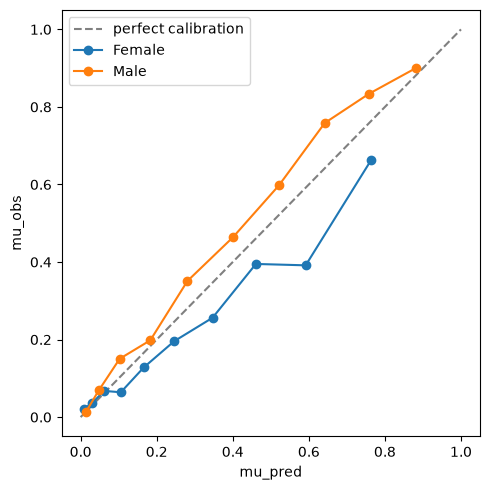

In [7]:
from sklearn.metrics import brier_score_loss

def calibration_table(y_true, y_proba, n_bins=15, min_bin_size=30):
    data = pd.DataFrame({"y_true": y_true, "y_proba": y_proba})
    data["bin"] = pd.qcut(data["y_proba"], q=n_bins)

    table = data.groupby("bin", observed=True).agg(
        mu_pred=("y_proba", "mean"),
        mu_obs=("y_true", "mean"),
        count=("y_true", "size"),
    ).reset_index()

    table["gap"] = (table["mu_pred"] - table["mu_obs"]).abs()
    table["reliable"] = table["count"] >= min_bin_size
    return table

def grouped_calibration_tables(y_true, y_proba, groups, n_bins=10):
    tables = {}
    for name, mask in groups.items():
        tables[name] = calibration_table(y_true[mask], y_proba[mask], n_bins=n_bins)
    return tables
    
def expected_calibration_error(c_table):
    total = c_table["count"].sum()
    return float((c_table["count"] / total * c_table["gap"]).sum())
        
def grouped_calibration_description(y_true, y_proba, groups, n_bins=10):
    descs = {}
    for name, mask in groups.items():
        table = calibration_table(y_true[mask], y_proba[mask], n_bins=n_bins)
        ece = expected_calibration_error(table)
        brier = brier_score_loss(y_true[mask], y_proba[mask])
        descs[name] = {"ECE":ece, "Brier":brier, "n":mask.sum()}
    return descs
    

def reliability_plot(y_true, y_proba, c_tables_grouped, n_bins=10, title=""):
    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")

    for name, c_table in c_tables_grouped.items():
        plt.plot(c_table["mu_pred"], c_table["mu_obs"], marker="o", label=name)

    plt.xlabel("mu_pred")
    plt.ylabel(f"mu_obs")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

c_table = calibration_table(validation[LABEL], lr_val_proba)
print("--- Overall Calibration Table ---")
display(c_table[["mu_pred", "mu_obs", "gap", "reliable"]])
print("Overall ECE: " + str(expected_calibration_error(c_table)))

groups = {group_val: (validation["SEX_group"] == group_val) for group_val in sorted(validation["SEX_group"].unique())}
c_tables_grouped = grouped_calibration_tables(validation[LABEL], lr_val_proba, groups=groups)
cal_descs = grouped_calibration_description(validation[LABEL], lr_val_proba, groups)
for name, c_table in c_tables_grouped.items():
    print(f"--- {name} Calibration Table ---")
    display(c_tables_grouped[name][["mu_pred", "mu_obs", "gap"]])
    for key, val in cal_descs[name].items():
        print(f"{key} = {val}")
    print("")
    

reliability_plot(validation[LABEL], lr_val_proba, c_tables_grouped=c_tables_grouped)

In [8]:
from fairlearn.postprocessing import ThresholdOptimizer

mitigator = ThresholdOptimizer(
    estimator=lr_model,
    constraints="equalized_odds",
    predict_method="predict_proba",
    prefit=True,
)
mitigator.fit(train[FEATURE_COLUMNS], train[LABEL], sensitive_features=train[SENSITIVE])

mitigated_pred = mitigator.predict(
    validation[FEATURE_COLUMNS],
    sensitive_features=validation[SENSITIVE],
    random_state=RANDOM_STATE,
)

def fairness_report_labels_only(y_true, y_pred, sensitive_df, title=""):
    mf = MetricFrame(metrics=LABEL_METRICS, y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_df)

    gaps = mf.difference(method="between_groups")
    print(f"{title}  |  TPR gap: {gaps['tpr']:.3f}, FPR gap: {gaps['fpr']:.3f}")

    plot_cols = [c for c in mf.by_group.columns if c != "count"]
    ax = mf.by_group[plot_cols].plot(kind="bar", figsize=(10, 4), title=title)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=7, rotation=90, padding=2)
    ax.set_ylim(0, np.nanmax(mf.by_group[plot_cols].values) * 1.25)
    plt.xticks(rotation=45, ha="right")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return mf

print("--- Before Mitigation ---")
fairness_summary(validation[LABEL], lr_val_pred, validation[["SEX_group"]])
print("------------------------------------------------")
print("--- After Mitigation ---")
fairness_summary(validation[LABEL], mitigated_pred, validation[["SEX_group"]])

--- Before Mitigation ---
Overall threshold metrics


count                6000.000000
selection_rate          0.296167
accuracy                0.786167
balanced_accuracy       0.745591
tpr                     0.623131
fpr                     0.131948
ppv                     0.703433
npv                     0.820980
dtype: float64

By group


,count,selection_rate,accuracy,balanced_accuracy,tpr,fpr,ppv,npv
SEX_group,,,,,,,,
Female,2812.0,0.216572,0.790541,0.692428,0.516026,0.13117,0.528736,0.862914
Male,3188.0,0.366374,0.782309,0.769300,0.671491,0.13289,0.794521,0.775248


equalized_odds_difference    0.155465
equalized_odds_ratio         0.768478
dtype: float64

------------------------------------------------
--- After Mitigation ---
Overall threshold metrics


count                6000.000000
selection_rate          0.343500
accuracy                0.755833
balanced_accuracy       0.729134
tpr                     0.648554
fpr                     0.190285
ppv                     0.631247
npv                     0.821021
dtype: float64

By group


,count,selection_rate,accuracy,balanced_accuracy,tpr,fpr,ppv,npv
SEX_group,,,,,,,,
Female,2812.0,0.292319,0.770270,0.724078,0.641026,0.192870,0.486618,0.887437
Male,3188.0,0.388645,0.743099,0.732400,0.651954,0.187154,0.727199,0.753207


equalized_odds_difference    0.010928
equalized_odds_ratio         0.970362
dtype: float64

## Week 2 : What to think about?

1. Audit plan and model cards for your baselines.
2. Observed-label performance, fairness, and calibration.
3. Label-quality evidence ?
4. Instability evidence?
5. Two competing explanations for your findings.
7. A clear separation between **observed evidence**, **hypothesis**, and **conclusion**.

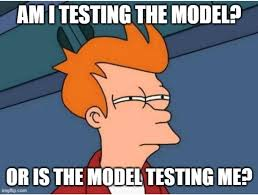

## 📝 Project 1 Submission Guidelines (Week 2 Contribution)

The investigations and hypotheses generated from this Week 2 notebook will form the second major section of your final A0 poster (~ another 1/3 of the poster).

When preparing your poster, ensure this section includes:
* Briefly outline the models and checks you used to establish performance and fairness baselines on the observed (but untrusted (?)) labels.
* *Highlight the most compelling evidence of data labels issue or generalizability issues you discovered (e.g., highly suspicious/unstable features, strange sub-group performances, or findings using popular frameworks).
* Present your strongest hypotheses explaining *why* these anomalies exist in the data. Clearly separate your observed data evidence from your conclusions about what real-world issues (such as systemic biases or collection flaws) might be causing them.
